# dynet-py: prepared inputs and table outputs

This tutorial uses a tiny, synthetic network with a known answer. Run the cells
from top to bottom, or use **Restart Kernel and Run All Cells**. No dataset download is needed.

You will prepare inputs once, calculate standardized rewiring, inspect flat
condition-comparison tables, make plots, and export CSV files. The optional final
sections demonstrate column aliases, input validation, and dense/sparse backends.

| What you want | Function | Result |
| --- | --- | --- |
| Standardized rewiring across networks | `rewiring_analysis` | DataFrame with `rewiring` |
| Changes in node degree | `compare_conditions` | DataFrame with `degree_change_score` |
| Gained, lost, or retained edges | `compare_conditions(..., output="edges")` | Edge DataFrame |
| Counts for each comparison | `compare_conditions(..., output="summary")` | Summary DataFrame |

**These are different metrics.** A node can change its neighbors while keeping
exactly the same degree. This example demonstrates that distinction.

## 1. Install the current repository version

From the repository's `dynet-py` directory, with your Python environment active, run:

```bash
python -m pip install -e . jupyterlab ipykernel
python -m jupyterlab examples/dynet_py_tutorial.ipynb
```

Use a kernel from that same environment. After pulling code updates or installing
the package, restart the kernel before running the notebook. The first cell checks
for the new table-output API; the package version alone does not identify a Git revision.

In [1]:
%matplotlib inline
from inspect import signature
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from dynet_py import (
    prepare_networks, rewiring_analysis, rewiring_plot,
    compare_targeting, calculate_jaccard_indices, small_multiples_plot,
    prepare_condition_data, compare_conditions, compare_condition_pair,
    plot_condition_changes, dynet_main,
)

if "output" not in signature(compare_conditions).parameters:
    raise RuntimeError(
        "This kernel is using an older dynet_py. Install the current repository "
        "with this kernel's Python interpreter, restart the kernel, and run again."
    )
pd.set_option("display.max_columns", 20)
print("The table-output API is available.")

The table-output API is available.


## 2. Make two networks

Use the canonical edge-list columns `source`, `target`, and optional `weight`.
If the weight column is omitted, weights default to 1.

- **T0:** A → B and C → D.
- **T1:** A → D and C → B.

Every node has one incident edge in each condition, but every edge changes.
All weights are 1, so both ordinary and weighted node degrees stay constant.

In [2]:
edge_lists = {
    "T0": pd.DataFrame({"source": ["A", "C"], "target": ["B", "D"], "weight": [1., 1.]}),
    "T1": pd.DataFrame({"source": ["A", "C"], "target": ["D", "B"], "weight": [1., 1.]}),
}
raw_conditions = pd.concat(
    [edges.assign(condition=name) for name, edges in edge_lists.items()],
    ignore_index=True,
)
display(raw_conditions)

,source,target,weight,condition
0,A,B,1.0,T0
1,C,D,1.0,T0
2,A,D,1.0,T1
3,C,B,1.0,T1


## 3. Prepare once and reuse

`prepare_networks` validates labels and finite numeric weights, aggregates
repeated edges, and creates a reusable snapshot. It caches the representations
needed by calculations and plots. Reusing an already prepared collection returns
the same object. If you edit the raw inputs, prepare them again to take a new snapshot.

This is preparation for the standardized-score workflow. The condition-comparison
workflow below has a separate preparation step for a single table containing conditions.

In [3]:
networks = prepare_networks(edge_lists)
assert prepare_networks(networks) is networks
print("Network order:", list(networks))
print("Shared node order:", networks.node_names)

Network order: ['T0', 'T1']
Shared node order: ('A', 'C', 'B', 'D')


## 4. Calculate standardized rewiring

`rewiring_analysis` returns a DataFrame directly. Its `rewiring` value summarizes
variation in incident edge weights after standardization across networks.

For this two-network example, **every node's rewiring score is 1**. The reported
`degree` is 2 because it counts incident edges in the union of the two networks;
therefore `degree_corrected_rewiring` is 0.5. This union degree differs from the
per-condition degrees used later.

The first plot shows the network union with node colors representing rewiring.
The following small panels show directed edges around node A in each condition.

In [4]:
rewiring = rewiring_analysis(networks)
assert isinstance(rewiring, pd.DataFrame)
np.testing.assert_allclose(rewiring["rewiring"], 1.)
np.testing.assert_allclose(rewiring["degree"], 2.)
np.testing.assert_allclose(rewiring["degree_corrected_rewiring"], 0.5)
display(rewiring)

,name,rewiring,degree,degree_corrected_rewiring
0,A,1.0,2.0,0.5
1,C,1.0,2.0,0.5
2,B,1.0,2.0,0.5
3,D,1.0,2.0,0.5


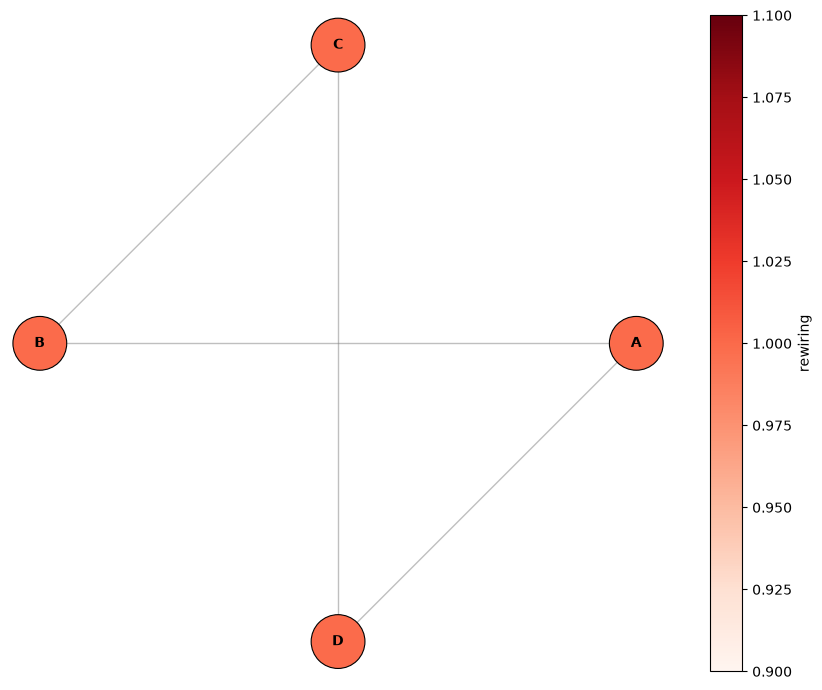

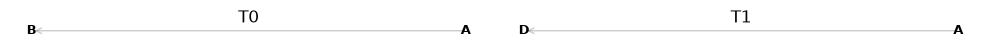

In [5]:
rewiring_figure = rewiring_plot(networks, rewiring)
display(rewiring_figure)
plt.close(rewiring_figure)

neighborhood_figure = small_multiples_plot(networks, focus_node="A")
display(neighborhood_figure)
plt.close(neighborhood_figure)

## 5. Reuse the same prepared networks for other calculations

Jaccard compares labeled, directed edges. These two networks share no edges, so
their Jaccard similarity is 0. Targeting compares sums of incoming weights;
those sums are unchanged here. Nodes with zero incoming weight in both networks
have an undefined `log2TargetingFC` (0/0), displayed as NaN.

In [6]:
jaccard = calculate_jaccard_indices(networks)
targeting = compare_targeting(networks)
assert jaccard.loc["T0", "T1"] == 0.
assert targeting["deltaTargeting"].eq(0).all()
display(jaccard)
display(targeting)

,T0,T1
T0,1.0,0.0
T1,0.0,1.0


,name,compared_networks,targetingNet1,targetingNet2,deltaTargeting,log2TargetingFC
0,A,1_vs_2,0.0,0.0,0.0,NaN
1,C,1_vs_2,0.0,0.0,0.0,NaN
2,B,1_vs_2,1.0,1.0,0.0,0.0
3,D,1_vs_2,1.0,1.0,0.0,0.0


## 6. Get condition-comparison tables

Prepare the single condition-labeled table once. Then choose the output you want:
`"nodes"` (default), `"edges"`, or `"summary"`. Each result is an ordinary pandas
DataFrame with `condition_a` and `condition_b` columns. The suffixes `_a` and `_b`
refer to those conditions; deltas are B minus A.

Specify condition order explicitly, especially for time series. With more than
two conditions, `pairwise="adjacent"` compares neighbors in that order and
`pairwise="all"` compares every selected pair.

In [7]:
condition_data = prepare_condition_data(raw_conditions)
condition_order = ["T0", "T1"]

nodes = compare_conditions(condition_data, conditions=condition_order)
edges = compare_conditions(condition_data, conditions=condition_order, output="edges")
summary = compare_conditions(condition_data, conditions=condition_order, output="summary")

assert all(isinstance(table, pd.DataFrame) for table in (nodes, edges, summary))
assert nodes["degree_change_score"].eq(0).all()
assert summary["n_gained"].tolist() == [2]
assert summary["n_lost"].tolist() == [2]
assert summary["n_kept"].tolist() == [0]

display(nodes[["condition_a", "condition_b", "node", "degree_a", "degree_b", "degree_change_score"]])
display(edges)
display(summary)

,condition_a,condition_b,node,degree_a,degree_b,degree_change_score
0,T0,T1,A,1.0,1.0,0.0
1,T0,T1,B,1.0,1.0,0.0
2,T0,T1,C,1.0,1.0,0.0
3,T0,T1,D,1.0,1.0,0.0


,comparison,condition_a,condition_b,source,target,status,weight_a,weight_b,delta_weight
0,T0_vs_T1,T0,T1,A,B,lost,1.0,0.0,-1.0
1,T0_vs_T1,T0,T1,A,D,gained,0.0,1.0,1.0
2,T0_vs_T1,T0,T1,C,B,gained,0.0,1.0,1.0
3,T0_vs_T1,T0,T1,C,D,lost,1.0,0.0,-1.0


,comparison,condition_a,condition_b,n_edges_a,n_edges_b,n_kept,n_lost,n_gained,n_nodes
0,T0_vs_T1,T0,T1,2,2,0,2,2,4


## 7. Access columns and filter rows directly

There is no need to navigate `result["comparisons"][0]["node_changes"]`.
Use regular pandas column selection and filtering. The full node table also
contains incoming/outgoing degrees, weight sums, and their totals.

`compare_condition_pair` returns the same table format for one explicit pair.

In [8]:
scores = nodes["degree_change_score"]
gained_edges = edges.loc[edges["status"] == "gained", ["source", "target", "weight_b"]]
pair_nodes = compare_condition_pair(condition_data, "T0", "T1")
pd.testing.assert_frame_equal(pair_nodes, nodes)
display(scores)
display(gained_edges)

0    0.0
1    0.0
2    0.0
3    0.0
Name: degree_change_score, dtype: float64

,source,target,weight_b
1,A,D,1.0
2,C,B,1.0


## 8. See why the two scores have different names

The condition-comparison heuristic is
`degree_change_score = abs(delta_degree) + abs(delta_weight_degree)`.
It is **0 for all four nodes** here because their degrees do not change.
Standardized `rewiring` is **1 for all four nodes** because their neighbors change.

Neither `compare_conditions` nor its historical name `dynet_main` calls the
standardized rewiring calculator. A zero degree-change score does not mean a node
kept its original neighbors.

In [9]:
score_comparison = rewiring[["name", "rewiring"]].rename(columns={"name": "node"}).merge(
    nodes[["node", "degree_change_score"]], on="node", validate="one_to_one",
)
assert score_comparison["rewiring"].eq(1).all()
assert score_comparison["degree_change_score"].eq(0).all()
display(score_comparison)

,node,rewiring,degree_change_score
0,A,1.0,0.0
1,C,1.0,0.0
2,B,1.0,0.0
3,D,1.0,0.0


## 9. Plot a table directly

The plotting function infers the plot type: a summary or edge table produces
edge counts, and a node table produces degree-change rankings. For multiple
comparisons, use `comparison=0`, `1`, and so on in appearance order.

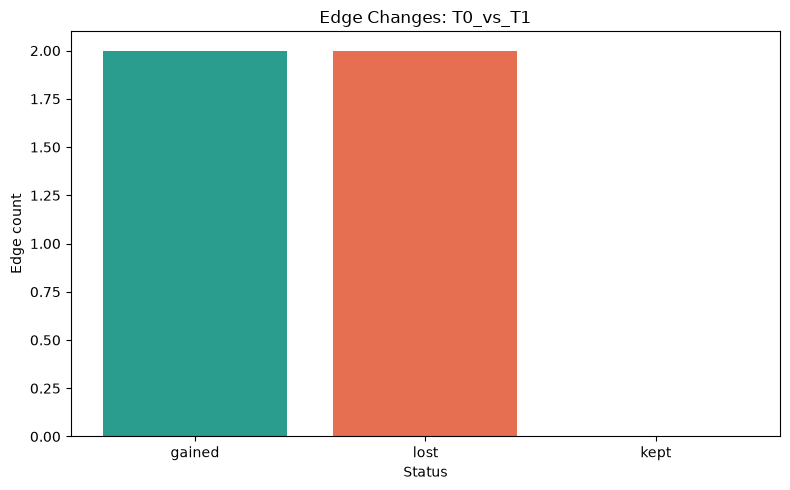

In [10]:
summary_figure = plot_condition_changes(summary)
display(summary_figure)
plt.close(summary_figure)

# You can also use plot_condition_changes(nodes) for the degree-change bars.
# All those bars would be zero for this example.

## 10. Optional: dense, sparse, and the 3D array

Both scoring backends should give the same values. `backend="auto"` is the default:
it selects sparse for at least 100,000 aligned tensor cells with at most 10%
nonzero entries, otherwise dense. This tiny example is not a speed benchmark.

The dense tensor has axes **(network, source node, target node)**. Calling
`adjacency_tensor()` explicitly materializes dense storage; it is unnecessary
when using the sparse backend on a large network. This toy tensor is small.

In [11]:
dense_scores = rewiring_analysis(networks, backend="dense")
sparse_scores = rewiring_analysis(networks, backend="sparse")
pd.testing.assert_frame_equal(dense_scores, sparse_scores, rtol=1e-12, atol=1e-12)

tensor = networks.adjacency_tensor()
assert tensor.shape == (2, 4, 4)
assert not tensor.flags.writeable
assert networks.adjacency_tensor() is tensor
print("Dense and sparse scores match. Tensor shape:", tensor.shape)
display(pd.DataFrame(tensor[0], index=networks.node_names, columns=networks.node_names))

Dense and sparse scores match. Tensor shape: (2, 4, 4)


,A,C,B,D
A,0.0,0.0,1.0,0.0
C,0.0,0.0,0.0,1.0
B,0.0,0.0,0.0,0.0
D,0.0,0.0,0.0,0.0


## 11. Optional: earlier column names and invalid weights

New code should use `source` and `target`. Input aliases `from`/`to` and `src`/`dst`
are still accepted and normalized during preparation. A table with multiple
endpoint pairs is ambiguous and rejected; keep just one pair.

Missing, nonnumeric, or infinite weights in a supplied weight column are rejected.
Omitting the weight column entirely is allowed and defaults to 1. The error below
is intentional and caught, so **Run All** can continue.

In [12]:
alias_inputs = {
    "T0": edge_lists["T0"].rename(columns={"source": "from", "target": "to"}),
    "T1": edge_lists["T1"].rename(columns={"source": "src", "target": "dst"}),
}
alias_scores = rewiring_analysis(prepare_networks(alias_inputs))
pd.testing.assert_frame_equal(alias_scores, rewiring)
print("Both earlier endpoint naming conventions produce the same scores.")

bad_edges = edge_lists["T0"].astype({"weight": object}).copy()
bad_edges.loc[0, "weight"] = "not a number"
try:
    prepare_networks({"bad_example": bad_edges})
except ValueError as error:
    print("Expected validation error:", error)
else:
    raise AssertionError("Invalid weights should have been rejected.")

Both earlier endpoint naming conventions produce the same scores.
Expected validation error: Network 'bad_example': Weights must be finite real numbers (numeric strings are accepted).


## 12. Optional: existing scripts

`dynet_main` and `dynet_internal` also return DataFrames by default. Prefer
`compare_conditions` and `compare_condition_pair` for their clearer names.

If an existing script needs the old nested structure, explicitly request
`output="legacy"`. On the historical entry points, `legacy_score_name=True`
restores the earlier `rewiring_score` column name only; that name still refers to
the degree-change heuristic, not standardized rewiring.

```python
legacy = dynet_main(condition_data, output="legacy", legacy_score_name=True)
```

In [13]:
legacy_entry_point_table = dynet_main(condition_data, conditions=condition_order)
pd.testing.assert_frame_equal(legacy_entry_point_table, nodes)
print("dynet_main also returns the same node DataFrame by default.")

dynet_main also returns the same node DataFrame by default.


## 13. Export results

This cell creates `tutorial_output/` in the notebook's working directory, containing
six CSV tables and two PNG plots. Rerunning it updates these tutorial output files.
Jaccard has meaningful row labels, so those labels are included when saving it.

In [14]:
output_dir = Path("tutorial_output")
output_dir.mkdir(exist_ok=True)

rewiring.to_csv(output_dir / "rewiring.csv", index=False)
nodes.to_csv(output_dir / "node_changes.csv", index=False)
edges.to_csv(output_dir / "edge_changes.csv", index=False)
summary.to_csv(output_dir / "comparison_summary.csv", index=False)
targeting.to_csv(output_dir / "targeting.csv", index=False)
jaccard.to_csv(output_dir / "jaccard.csv", index_label="network")
rewiring_figure.savefig(output_dir / "rewiring.png", dpi=120, bbox_inches="tight")
summary_figure.savefig(output_dir / "edge_counts.png", dpi=120, bbox_inches="tight")

restored_nodes = pd.read_csv(output_dir / "node_changes.csv")
pd.testing.assert_frame_equal(restored_nodes, nodes, check_dtype=False)
display(pd.DataFrame({"saved_file": sorted(path.name for path in output_dir.iterdir())}))
print("All tutorial checks passed.")

,saved_file
0,comparison_summary.csv
1,edge_changes.csv
2,edge_counts.png
3,jaccard.csv
4,node_changes.csv
5,rewiring.csv
6,rewiring.png
7,targeting.csv


All tutorial checks passed.


## Try your own data

Keep this notebook as a known-answer example. In a new notebook, replace the toy
input with your CSV files and copy the preparation, analysis, plotting, and export
steps. Omit the assertions that expect this example's exact scores.

```python
edge_lists = {
    "control": pd.read_csv("control.csv"),
    "treated": pd.read_csv("treated.csv"),
}
networks = prepare_networks(edge_lists)
rewiring = rewiring_analysis(networks)

condition_data = prepare_condition_data(pd.concat(
    [frame.assign(condition=name) for name, frame in edge_lists.items()],
    ignore_index=True,
))
nodes = compare_conditions(condition_data, conditions=["control", "treated"])
```

For comparison tables, rows define edge presence even at zero weight and
self-loops are removed by default. For standardized rewiring, zero weights mean
absent edges. Choose the workflow appropriate for the question you want to answer.
See the [API reference](https://github.com/korcsmarosgroup/dynet-pipeline/blob/main/dynet-py/docs/api.md)
for the full schemas and options.